In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("archive/house_prices.csv")[['Amount(in rupees)', 'Carpet Area', 'Transaction', 'Furnishing',
        'Society', 'Bathroom', 'Balcony']]

# Defining Formatters

`format_amount` - Converts data into **Lac** numeric values  
`format_area  `   - Converts data into **Sqm** numeric values

In [3]:
def format_amount(x: str) -> int: # convert to lacs
    x = x.strip()
    if x.endswith("Lac"):
        x = float(x.replace("Lac", ""))
    elif x.endswith("Cr"):
        x = float(x.replace("Cr", "")) * 100
    else:
        x = None
    return x

def format_area(x: str) -> float:
    if not isinstance(x, str): return None
    x = x.lower().strip()
    try:
        val = float(''.join(c for c in x if c.isdigit() or c == '.'))
    except ValueError:
        return None
    
    if "sqft" in x:
        return val * 0.0929
    elif "sqm" in x:
        return val
    elif "qyrd" in x:
        return val * 0.8361
    elif "acre" in x:
        return val * 4046.86
    elif "ound" in x: # Ground
        return val * 222.97
    elif "igha" in x: # Bigha
        return val * 2529.3
    elif "arla" in x: # Marla
        return val * 25.29
    elif "anal" in x: # Kanal
        return val * 505.86
    else:
        return None


# Cleaning Dataset
  
`Amount` - transform and remove outliers  
`Carpet` - remove nan and scale  
`Transa` - label encode remove nan  
`Furnis` - label encode remove nan  
`Societ` - Label encode (acc. to avg house price there)  
`Bathro` - remove nan Label encode  
`Balcon` - remove nan Label encode  

In [4]:

df['Amount(in rupees)'] = df['Amount(in rupees)'].map(format_amount)

df['Carpet Area'] = df['Carpet Area'].map(format_area)

df = df[df['Transaction'] != 'Other'] # removed since only two training examples have it 
df['Transaction'] = df['Transaction'].map(lambda x: 1 if x=='New Property' else 0 if x=='Resale' else None)

df['Furnishing'] = df['Furnishing'].map(lambda x: 2 if x=='Furnished' else 1 if x=='Semi-Furnished' else 0 if x=='Unfurnished' else None)

df['Society'] = df['Society'].fillna('Private')

label = df.groupby('Society', observed=True)['Amount(in rupees)'].mean().sort_values() # Label encoding Society based on avg Hous price of it
df["Society"] = df['Society'].map(lambda x : label[x])

df['Balcony'] = df['Balcony'].replace('> 10', '11').astype('Int8')

df['Bathroom'] = df['Bathroom'].replace('> 10', '11').astype('Int8')


df = df.dropna()

# Defining Optimisation and utility functions

`        Cost       ` - Computes the Mean Squared Error between model predictions and true targets.  
`       Gradient    ` - Computes the gradients of the MSE loss with respect to weights W and bias b.  
` Gradient Descent` - Iteratively updates W and b using gradient descent while recording the cost history.  
`Data Verification` - Validates input types, dimensions, and shape compatibility before model computation.  
</br>

| Considerations | |
| :-- | :-- |  
|`W` - Vector of weights     | `b` - Scalar base value |
|`x` - Vector of inputs      | `y` - Scalar output |
|`X` - Matrix of Input    | `Y` - Vector of output |

In [5]:
def model(x: np.ndarray, W: np.ndarray, b: float) -> float:
    dataVerification(x=x, W=W, b=b)
    
    y = X.dot(W) + b
    return y


def cost(X: np.ndarray, W: np.ndarray, b: float, Y: np.ndarray) -> float:
    dataVerification(X=X, W=W, b=b, Y=Y)
    
    prediction = X @ W + b
    cost = np.mean( (prediction - Y)**2 )
    return cost


def gradient(X: np.ndarray, W: np.ndarray, b: float, Y: np.ndarray) -> (np.ndarray, float):
    err = (X @ W + b - Y)
    
    grad_W = (X.T * err).mean(axis=1) * 2
    grad_b = err.mean() *2
    return grad_W, grad_b


def gradientDescent(X: np.ndarray, W: np.ndarray, b: float, Y: np.ndarray, a: float, k: int) -> (list, np.ndarray, float):
    dataVerification(X=X, W=W, b=b, Y=Y, a=a, k=k)
    
    history = [cost(X, W, b, Y)]
    
    for i in range(k):
        grad_W, grad_b = gradient(X, W, b, Y)
        W = W - a*grad_W
        b = b - a*grad_b

        history.append(cost(X,W,b,Y))
    
    return (history, W, b)


def dataVerification(
        x: np.ndarray = None,
        X: np.ndarray = None,
        W: np.ndarray = None,
        b: float = None,
        Y: np.ndarray = None,
        a: float = None,
        k: int = None,
    ):

    # --- Type checks ---
    if W is not None and not isinstance(W, np.ndarray):
        raise TypeError("W must be a NumPy array.")

    if x is not None and not isinstance(x, np.ndarray):
        raise TypeError("x must be a NumPy array.")

    if X is not None and not isinstance(X, np.ndarray):
        raise TypeError("X must be a NumPy array.")

    if Y is not None and not isinstance(Y, np.ndarray):
        raise TypeError("Y must be a NumPy array.")

    if b is not None and not np.isscalar(b):
        raise TypeError("b must be a scalar.")

    if a is not None:
        if not isinstance(a, (int, float)) or a <= 0:
            raise ValueError("Learning rate 'a' must be positive.")

    if k is not None:
        if not isinstance(k, int) or k <= 0:
            raise ValueError("Iterations 'k' must be a positive integer.")

    # --- Model-level checks (single sample) ---
    if x is not None and W is not None:
        if x.ndim != 1:
            raise ValueError(f"x must be 1D (n,). Got shape {x.shape}")
        if W.ndim != 1:
            raise ValueError(f"W must be 1D (n,). Got shape {W.shape}")
        if x.shape[0] != W.shape[0]:
            raise ValueError(
                f"Shape mismatch: x has {x.shape[0]} features, "
                f"but W has {W.shape[0]} weights."
            )

    # --- Dataset-level checks ---
    if X is not None and W is not None:
        if X.ndim != 2:
            raise ValueError(f"X must be 2D (m, n). Got shape {X.shape}")
        if W.ndim != 1:
            raise ValueError(f"W must be 1D (n,). Got shape {W.shape}")

        m, n = X.shape

        if W.shape[0] != n:
            raise ValueError(
                f"Shape mismatch: W has {W.shape[0]} weights "
                f"but X has {n} features."
            )

        if Y is not None:
            if Y.ndim != 1:
                raise ValueError(f"Y must be 1D (m,). Got shape {Y.shape}")
            if Y.shape[0] != m:
                raise ValueError(
                    f"Shape mismatch: Y has {Y.shape[0]} samples "
                    f"but X has {m} samples."
                )


# Dropping Outliers

Agressivley dropping any coumn containing outliers  
since we retain almost 98% of cleaned data even after that  

Z-score < -3 : Outlier  
Z-score >  3 : Outlier  

`    Z-score    ` = (x - mean) / std  

In [6]:
df = df[((abs(df - df.mean()) / df.std())<3).all(axis=1)]

# Preparing Data

`X train` - (m, n)	Training features  
`Y train` - (m,)	Training targets  
`X test	` - (m_test, n)	Test features  
`Y test	` - (m_test,)	Test targets  

`Scaled Data` - all the data is standardized in accordance with training data  
at the end we will performing descaling on predicted values  
</br>
| DataFrame | |
|:-- |:--|
| X test | Y test |
| X train | Ytrain|

In [7]:
SPLIT         = 0.70   # 70% train data, 30% test data
ITERATIONS    = 500
LEARNING_RATE = 1e-2
WEIGHTS       = np.zeros(6) # 6 features in dataset (7-1 columns)
BASE          = 0.0

# Shuffling Dataset
df_Shuffle = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_train = df_Shuffle[ : int(len(df) * SPLIT)]
df_test  = df_Shuffle[ int(len(df) * SPLIT) : ]

X_train = df_train[['Carpet Area', 'Transaction', 'Furnishing', 'Society', 'Bathroom', 'Balcony']].to_numpy(dtype=np.float64)
Y_train = df_train['Amount(in rupees)'].to_numpy(dtype=np.float64)

X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)
X_std[X_std == 0] = 1

Y_mean = Y_train.mean()
Y_std  = Y_train.std()

# Scaling Test
X_train_scaled = (X_train - X_mean) / X_std
Y_train_scaled = (Y_train - Y_mean) / Y_std



X_test = df_test[['Carpet Area', 'Transaction', 'Furnishing', 'Society', 'Bathroom', 'Balcony']].to_numpy(dtype=np.float64)
Y_test = df_test['Amount(in rupees)'].to_numpy(dtype=np.float64)

# Scaling train using train set stats
X_test_scaled = (X_test - X_mean) / X_std
Y_test_scaled = (Y_test - Y_mean) / Y_std


# Implementing Optimization function

In [8]:
%%time

hist, w, b = gradientDescent(X_train_scaled, WEIGHTS, BASE, Y_train_scaled, LEARNING_RATE, ITERATIONS)

CPU times: user 1.47 s, sys: 3.83 ms, total: 1.47 s
Wall time: 1.49 s


# Visualising Data
We have total 7+1 dimentions of data(Weight and Bias), but for visualization pourposes we set 6 of the Weights at their optimal values and vary W0 and B for countour and surface plot of cost functions 


`Cost vs Iterations (Top Left)     ` - Cost vs Iterations (Top Left)  
`Contour Plot of Cost (Bottom Left)` - This contour plot represents level sets of the cost function with respect to [Weight0, Bias]  
`Wireframe of Cost Surface (Right) ` - This plot shows the full 3D shape of the cost function [Weight0, Bias, Cost]

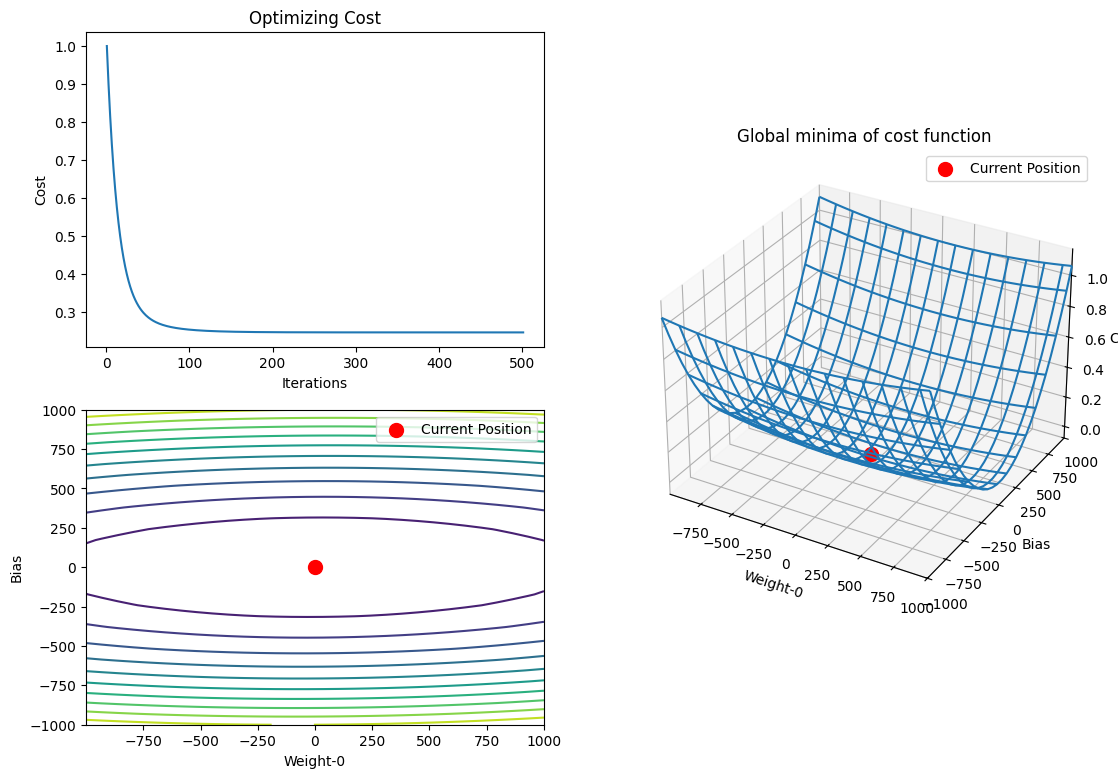

In [9]:
fig, axs = plt.subplot_mosaic([ ["1", "3"], ["2", "3"] ], figsize=(13, 9))
fig.delaxes(axs["3"])
axs["3"] = fig.add_subplot(1, 2, 2, projection='3d')


axs["1"].set_title("Optimizing Cost")
axs["1"].set_xlabel("Iterations")
axs["1"].set_ylabel("Cost")
axs["1"].plot(np.arange(1, len(hist)+1, 1), hist)




W0_vals = np.linspace(w[0]-1e3, w[0]+1e3, 30)
b_vals = np.linspace(b-1e3, b+1e3, 30)
W0, B = np.meshgrid(W0_vals, b_vals)
J = np.zeros_like(W0)

X_small = X_train_scaled[:2000]
Y_small = Y_train_scaled[:2000]

for i in range(W0.shape[0]):
    for j in range(B.shape[1]):
        W_temp = w.copy()
        W_temp[0] = W0[i,j]
        
        J[i, j] = cost(X_small, W_temp, B[i, j], Y_small)

current_cost = cost(X_small, w, b, Y_small)



axs['2'].set_xlabel("Weight-0")
axs['2'].set_ylabel("Bias")
axs['2'].set_xlim(W0.min(), W0.max())
axs['2'].set_ylim(B.min(), B.max())
axs['2'].contour(W0, B, J, levels=10)
axs['2'].scatter(w[0], b, color='red', s=100, label='Current Position')
axs['2'].legend()



axs['3'].set_title("Global minima of cost function")
axs['3'].set_xlabel("Weight-0")
axs['3'].set_ylabel("Bias")
axs['3'].set_zlabel("Cost")
axs['3'].set_xlim(W0.min(), W0.max())
axs['3'].set_ylim(B.min(), B.max())
axs['3'].scatter(w[0], b, current_cost, color='red', s=100, label='Current Position')
axs['3'].legend()
axs['3'].plot_wireframe(W0, B, J, rstride=2, cstride=2)


plt.show()

# Testing Model

In [10]:
print(f'''
MODEL ->
prediction = x0*{w[0]} + x1*{w[1]} + x2*{w[2]} + x3*{w[3]} + x4*{w[4]} + x5*{w[5]} + {b}
''')


MODEL ->
prediction = x0*0.02746827526534142 + x1*0.046062805033581775 + x2*-0.00314978146839839 + x3*0.5970248826334771 + x4*0.3627570476446577 + x5*0.015174641657077208 + 8.326422680112511e-17



np.float64(0.2511653148940627)

In [11]:
Y_predicted_scaled = (X_test_scaled @ w + b)

# descaling predicted y values
Y_predicted = Y_predicted_scaled * Y_std + Y_mean

# calculating error
error = np.mean(np.abs(Y_test - Y_predicted))
print("Mean absolute Error: ", error)

Mean absolute Error:  40.60265985986473


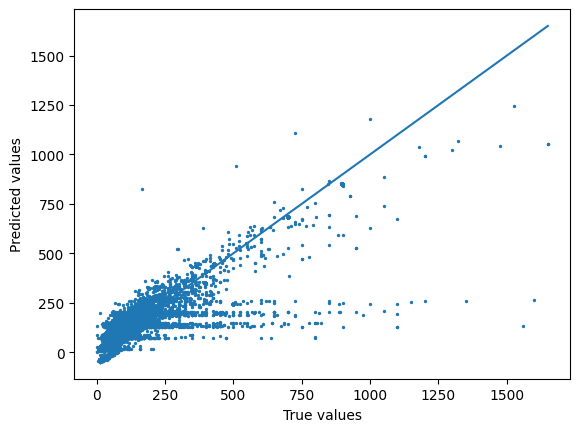

In [12]:
plt.scatter(Y_test, Y_predicted, s=2)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.plot([min(Y_test), max(Y_test)],
         [min(Y_test), max(Y_test)])


plt.show()